# Classroom AV Support Ticket Analysis

**Analyzing 18 months of ServiceNow-style AV support tickets across 22 classrooms
to identify recurring issue patterns, resolution-time trends, and the root cause
behind a cluster of repeat support requests.**

> ⚠️ **All data in this project is synthetic.** Real ServiceNow data from the role this
> project is based on is confidential and cannot be shared. Instead,
> [`scripts/generate_data.py`](../scripts/generate_data.py) generates a dataset whose
> *aggregate statistical shape* — volume, seasonality, issue mix, resolution-time
> distribution, data-quality quirks — was calibrated against summary statistics from a
> real export. No real records, rooms, names, or free text appear here. Findings below
> are findings about the synthetic dataset, demonstrating the analytical workflow.

**Questions this analysis answers**

1. What does this ticket queue actually consist of, once automation noise is removed?
2. Where is volume concentrated — by time of year, classroom, and issue category?
3. How long do tickets really take to resolve, and what drives the slow half?
4. Which classrooms generate disproportionate *repeat* tickets — and is there a
   specific AV configuration pattern behind them?


In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

warnings.filterwarnings("ignore", category=FutureWarning)

# --- House style: consistent, colorblind-validated palette ------------------
CONFIG_COLORS = {
    "nvx_standard": "#2a78d6",     # blue  — modern standardized config (baseline)
    "legacy_matrix_v1": "#eb6834", # orange — legacy HDMI matrix config (the pattern)
    "nvx_early": "#1baf7a",        # aqua  — early NVX rollout config
}
CONFIG_LABELS = {
    "nvx_standard": "NVX standard",
    "legacy_matrix_v1": "Legacy matrix",
    "nvx_early": "NVX early rollout",
}
SEQ_BLUES = ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#184f95", "#0d366b"]

INK, INK_2, MUTED, GRID = "#0b0b0b", "#52514e", "#898781", "#e1e0d9"
plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.edgecolor": "#c3c2b7", "axes.labelcolor": INK_2,
    "axes.titlecolor": INK, "axes.titlesize": 13, "axes.titleweight": "bold",
    "axes.spines.top": False, "axes.spines.right": False,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "font.family": "sans-serif", "font.size": 10.5,
    "figure.dpi": 110, "savefig.dpi": 150, "savefig.bbox": "tight",
})

FIG_DIR = Path("../dashboard/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

def style_ax(ax):
    ax.grid(axis="x", visible=False)
    ax.set_axisbelow(True)

def style_axh(ax):
    ax.grid(axis="y", visible=False)
    ax.grid(axis="x", visible=True)
    ax.set_axisbelow(True)


## 1. Load the data

Two files, mirroring what you'd actually pull at work:

- **`av_tickets.csv`** — a raw ServiceNow incident export (one row per ticket, warts
  and all)
- **`classrooms.csv`** — a room inventory export from the AV asset database
  (equipment loadout, configuration variant, last refresh date)

The AV configuration lives in the *asset* table, not the ticket table — exactly like
production systems — so surfacing config-level patterns requires a join.

In [2]:
tickets_raw = pd.read_csv("../data/av_tickets.csv")
rooms = pd.read_csv("../data/classrooms.csv", parse_dates=["last_av_refresh"])

print(f"{len(tickets_raw):,} raw rows | {len(rooms)} classrooms")
tickets_raw.head(3)

2,546 raw rows | 22 classrooms


,ticket_id,created_at,resolved_at,created_by,classroom_id,building,category,subcategory,description,resolution_notes,assigned_technician,resolution_time_minutes
0,INC0201474,2025-01-05 07:50:49,2025-01-05 07:58:49,25Live,WIE-105,Wieboldt Hall,Classroom Scheduling,Room reservation sync,MORS-470-0-51 Negotiations,Auto-closed by scheduling integration.,NaN,18.0
1,INC0202485,2025-01-06 05:27:36,NaN,25Live,WIE-412,Wieboldt Hall,Classroom Scheduling,Room reservation sync,ACCT-410-0-51 Financial Accounting,NaN,NaN,NaN
2,INC0201685,2025-01-06 05:30:44,2025-01-06 05:53:44,25Live,WIE-110,Wieboldt Hall,Classroom Scheduling,Room reservation sync,Faculty Meeting,Auto-closed by scheduling integration.,NaN,27.0


In [3]:
# What is this export actually made of?
tickets_raw.groupby("created_by").size().sort_values(ascending=False).head(5)

created_by
25Live            1802
Faculty6857660       2
Staff5911365         2
Faculty8742043       2
Student6125096       2
dtype: int64

**First discovery, before any analysis:** the largest "requester" in the export is
`25Live` — the room-scheduling system. Its integration files an incident row for every
reservation sync, and those rows are **~70% of the export**. Any volume metric computed
on the raw file would be measuring the booking calendar, not support demand. Filtering
this out is the single most consequential cleaning step in the project.

## 2. Data cleaning

Issues found in the raw export (all typical of real ServiceNow data):

| Problem | Evidence | Decision |
|---|---|---|
| Scheduling-automation rows | `created_by == "25Live"`, category "Classroom Scheduling" | Exclude — they are calendar syncs, not support tickets |
| Timestamps stored as strings | `object` dtype on both date columns | Parse to `datetime64` |
| Missing room attribution | ~30% of human tickets have a blank `classroom_id` | Keep for volume/time metrics; exclude from room-level analysis (documented bias) |
| Inconsistent category casing | `Webconferencing` vs `WEBCONFERENCING` | Normalize to canonical values |
| Whitespace-padded room IDs | `"WIE-142 "` fails the join to the room table | `str.strip()` |
| Open tickets | ~6% have no `resolved_at` | Keep for volume metrics; exclude from resolution-time metrics (don't impute) |
| Duplicate submissions | Same room + issue re-filed minutes apart | Flag (same room + subcategory within 15 min) and exclude from counts |


In [4]:
t = tickets_raw.copy()

# 1) Remove scheduling-automation noise
t = t[t["created_by"] != "25Live"].copy()
print(f"After removing scheduling automation: {len(t):,} human tickets "
      f"({1 - len(t)/len(tickets_raw):.0%} of raw rows removed)")

# 2) Parse timestamps
t["created_at"] = pd.to_datetime(t["created_at"])
t["resolved_at"] = pd.to_datetime(t["resolved_at"])

# 3) Normalize messy text fields
t["classroom_id"] = t["classroom_id"].fillna("").str.strip()
canonical = ["AV Technical Support", "Lecture Capture", "Webconferencing",
             "Equipment Maintenance & Repair", "Setup & Configuration", "Consultation"]
category_map = {c.lower(): c for c in canonical}
t["category"] = t["category"].str.lower().map(category_map)
assert t["category"].notna().all(), "Unmapped category values remain"

# 4) Flag duplicate submissions: same room + subcategory filed within 15 minutes
t = t.sort_values("created_at")
has_room = t["classroom_id"] != ""
gap = t[has_room].groupby(["classroom_id", "subcategory"])["created_at"].diff()
t["is_duplicate"] = gap.le(pd.Timedelta(minutes=15)).reindex(t.index).fillna(False)

# 5) Open tickets & missing rooms
t["is_open"] = t["resolved_at"].isna()
t["has_room"] = t["classroom_id"] != ""

print(f"Duplicates flagged:   {t.is_duplicate.sum()} ({t.is_duplicate.mean():.1%})")
print(f"Open tickets:         {t.is_open.sum()} ({t.is_open.mean():.1%})")
print(f"Missing room number:  {(~t.has_room).sum()} ({(~t.has_room).mean():.0%})")

tickets = t[~t.is_duplicate].copy()

# 6) Join room attributes for tickets that have a room
tickets = tickets.merge(rooms[["classroom_id", "seats", "config_variant", "last_av_refresh"]],
                        on="classroom_id", how="left", validate="many_to_one")
assert tickets.loc[tickets.has_room, "config_variant"].notna().all(), "Join failed for attributed rooms"

tickets["month"] = tickets["created_at"].dt.to_period("M").dt.to_timestamp()
tickets["hour"] = tickets["created_at"].dt.hour
tickets["config_label"] = tickets["config_variant"].map(CONFIG_LABELS)
tickets["res_hours"] = tickets["resolution_time_minutes"] / 60

print(f"\nClean working set: {len(tickets):,} tickets "
      f"({tickets.has_room.sum():,} with room attribution)")

After removing scheduling automation: 744 human tickets (71% of raw rows removed)
Duplicates flagged:   7 (0.9%)
Open tickets:         34 (4.6%)
Missing room number:  198 (27%)

Clean working set: 737 tickets (539 with room attribution)


**On the 30% missing rooms:** those tickets stay in every volume, category, and
time metric, but room-level comparisons can only use attributed tickets. That's a
real bias worth naming: if certain issue types are less likely to get a room recorded
(e.g., consultations), room-level rates are computed on a non-random subset. It's also
an immediate, free process recommendation — **make the room field required on the AV
request form** — that would improve every future analysis.

## 3. What does AV support demand actually look like?

### 3.1 Volume tracks the academic calendar — spring is the peak, not fall

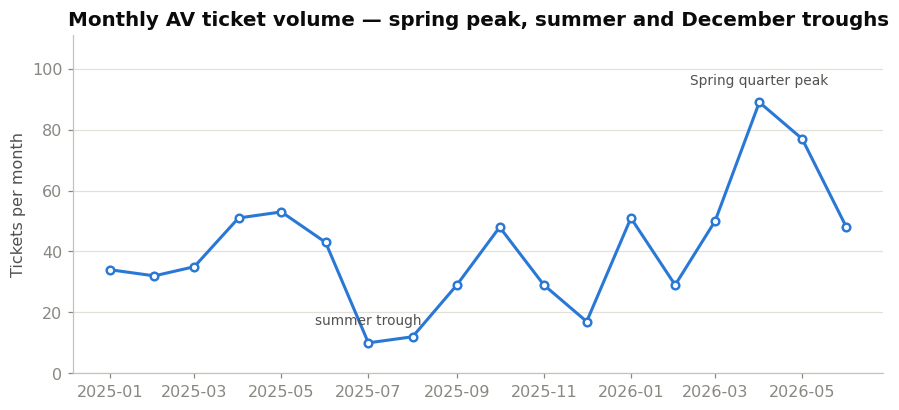

Jan–Jun 2025: 248 tickets | Jan–Jun 2026: 344 tickets (+39% YoY)


In [5]:
monthly = tickets.groupby("month").size()

fig, ax = plt.subplots(figsize=(9.5, 4))
ax.plot(monthly.index, monthly.values, color="#2a78d6", linewidth=2,
        marker="o", markersize=5, markerfacecolor="white", markeredgewidth=1.6)
style_ax(ax)
ax.annotate("Spring quarter peak", xy=(pd.Timestamp("2026-04-01"), monthly[pd.Timestamp("2026-04-01")]),
            xytext=(0, 12), textcoords="offset points", ha="center", fontsize=9, color=INK_2)
ax.annotate("summer trough", xy=(pd.Timestamp("2025-07-01"), monthly[pd.Timestamp("2025-07-01")]),
            xytext=(0, 12), textcoords="offset points", ha="center", fontsize=9, color=INK_2)
ax.set_title("Monthly AV ticket volume — spring peak, summer and December troughs")
ax.set_ylabel("Tickets per month")
ax.set_xlabel("")
ax.set_ylim(0, monthly.max() * 1.25)
fig.savefig(FIG_DIR / "monthly_volume.png")
plt.show()

y1 = monthly[monthly.index < "2026-01-01"]["2025-01":"2025-06"].sum() if False else monthly.loc["2025-01":"2025-06"].sum()
y2 = monthly.loc["2026-01":"2026-06"].sum()
print(f"Jan–Jun 2025: {y1} tickets | Jan–Jun 2026: {y2} tickets ({y2/y1-1:+.0%} YoY)")

Two operational facts fall out: demand peaks in the **spring quarter** (April–June)
with deep troughs in summer and December — so the natural preventative-maintenance
windows are the quiet weeks *before* January and *before* late March. And volume is
growing **year over year**, which makes prevention a staffing argument, not just a
convenience.

### 3.2 What the work actually is — lecture capture is the biggest single bucket

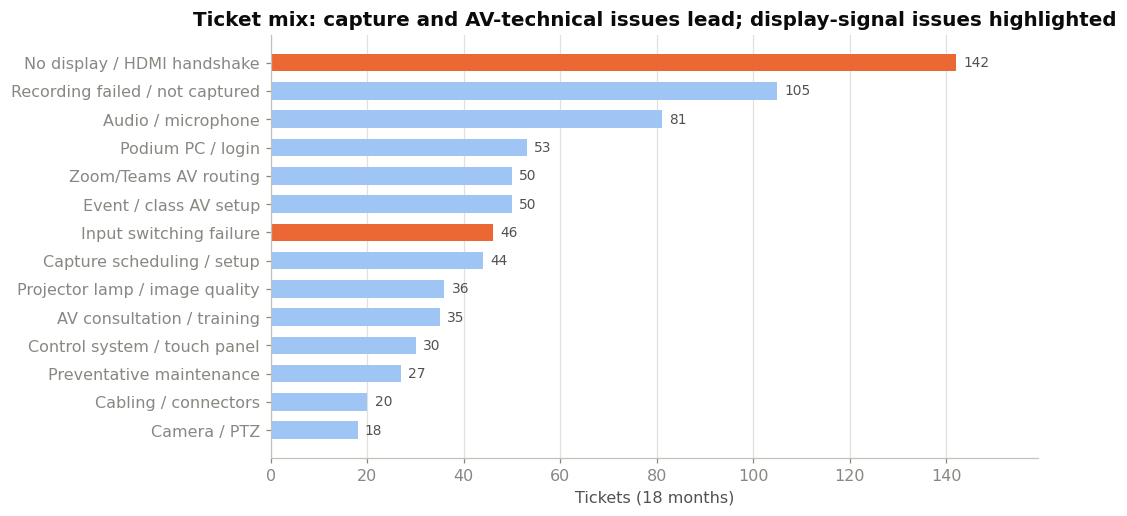

Lecture Capture share: 20% | Display-signal share: 26%


In [6]:
sub_counts = tickets.groupby(["category", "subcategory"]).size().sort_values()

fig, ax = plt.subplots(figsize=(9, 5))
colors = ["#eb6834" if s in ("No display / HDMI handshake", "Input switching failure")
          else "#9ec5f4" for s in sub_counts.index.get_level_values(1)]
ax.barh(sub_counts.index.get_level_values(1), sub_counts.values, color=colors, height=0.62)
style_axh(ax)
for i, v in enumerate(sub_counts.values):
    ax.text(v + 1.5, i, f"{v}", va="center", fontsize=9, color=INK_2)
ax.set_title("Ticket mix: capture and AV-technical issues lead; display-signal issues highlighted")
ax.set_xlabel("Tickets (18 months)")
ax.set_xlim(0, sub_counts.max() * 1.12)
fig.savefig(FIG_DIR / "subcategory_mix.png")
plt.show()

sig_share = sub_counts.loc[:, ["No display / HDMI handshake", "Input switching failure"]].sum() / len(tickets)
cap_share = tickets.category.eq("Lecture Capture").mean()
print(f"Lecture Capture share: {cap_share:.0%} | Display-signal share: {sig_share:.0%}")

Lecture capture is the largest single category — recordings that silently fail are
discovered *after* class, when recovery options are limited, which makes capture
monitoring its own preventative opportunity. But the two **display-signal**
subcategories (HDMI handshake + input switching, highlighted orange) are the thread the
rest of this analysis pulls: they're the classic *class-blocking, call-us-right-now*
failure, and they turn out to be heavily concentrated.

### 3.3 When demand arrives — mid-day peak with an evening-program tail

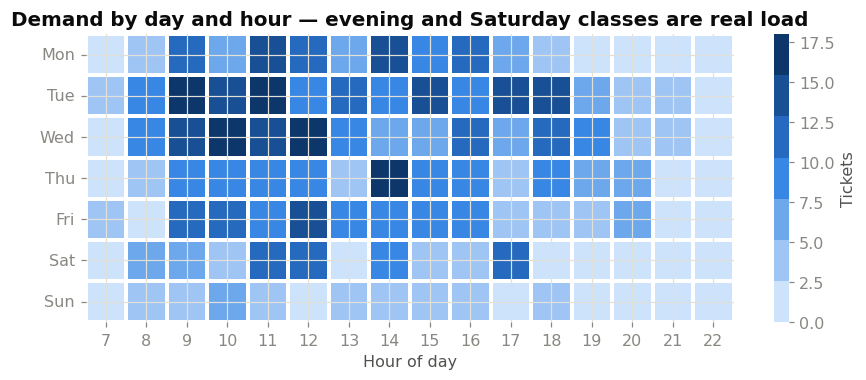

In [7]:
dow_hour = (tickets.assign(dow=tickets.created_at.dt.dayofweek)
            .groupby(["dow", "hour"]).size().unstack(fill_value=0)
            .reindex(index=range(7), fill_value=0))
dow_hour.index = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

fig, ax = plt.subplots(figsize=(9.5, 3.4))
sns.heatmap(dow_hour, cmap=sns.color_palette(SEQ_BLUES, as_cmap=True),
            linewidths=1.5, linecolor="white",
            cbar_kws={"label": "Tickets"}, ax=ax)
ax.set_title("Demand by day and hour — evening and Saturday classes are real load")
ax.set_xlabel("Hour of day"); ax.set_ylabel("")
ax.tick_params(rotation=0)
fig.savefig(FIG_DIR / "dow_hour_heatmap.png")
plt.show()

Coverage implication: demand isn't 9-to-5. Tuesday–Thursday mid-days dominate, but
the evening-program tail (to ~9 PM) and Saturday sessions carry real volume — relevant
for both staffing and for *when* preventative checks can run without disrupting classes.

## 4. How long do tickets take? (calendar time, honestly)

`resolution_time_minutes` here is **calendar duration** — request to resolution,
queue time included — not hands-on labor. That's what the timestamps in a ticket
system actually measure, and it's the customer's experience of waiting.

In [8]:
resolved = tickets[~tickets.is_open].copy()
r = resolved["res_hours"]
print(f"Resolved tickets: {len(resolved):,}")
print(f"p25: {r.quantile(.25):.1f}h | median: {r.quantile(.5):.1f}h | "
      f"p75: {r.quantile(.75):.1f}h | p90: {r.quantile(.9):.0f}h")
print(f"Resolved within 1 hour: {(r <= 1).mean():.0%}")
print(f"Resolved same day (<24h): {(r <= 24).mean():.0%}")

Resolved tickets: 703
p25: 2.1h | median: 15.3h | p75: 99.0h | p90: 502h
Resolved within 1 hour: 19%
Resolved same day (<24h): 57%


In [9]:
med_by_cat = (resolved.groupby("category")["res_hours"]
              .agg(median_hours="median", p90_hours=lambda s: s.quantile(0.9), n="size")
              .round(1).sort_values("median_hours"))
med_by_cat

,median_hours,p90_hours,n
category,,,
AV Technical Support,3.7,88.3,344
Webconferencing,13.5,180.4,63
Lecture Capture,54.0,683.8,143
Consultation,125.9,843.2,32
Equipment Maintenance & Repair,141.6,664.3,76
Setup & Configuration,162.7,931.2,45


The distribution is extremely wide — a meaningful share resolved within the hour
(technician dispatched mid-class), while half of everything takes more than a day and
the slow tail runs to weeks (parts, scheduling, low-urgency projects). This is why
**every summary here is a median or percentile, never a mean**: the mean is pulled an
order of magnitude above the typical ticket by the project-shaped tail.

The category table shows the queue is really two kinds of work: *interrupt-driven
fixes* (AV technical, webconferencing — medians in hours) and *scheduled work*
(maintenance, setup, consultation — medians in days). Any resolution-time SLA or
trend analysis has to separate them.

### 4.1 A trap: comparing room types on overall resolution time

In [10]:
# Naive comparison: overall median resolution by configuration (attributed rooms)
resolved[resolved.has_room].groupby("config_label")["res_hours"].median().round(1)

config_label
Legacy matrix         7.9
NVX early rollout    14.2
NVX standard         23.2
Name: res_hours, dtype: float64

Legacy-matrix rooms look *faster*, not slower — because their ticket mix skews
toward interrupt-driven display fixes, which resolve in hours, while standardized rooms
carry relatively more multi-day scheduled work. **The honest comparison is
like-for-like: the same issue types across room groups.**

Display-signal issues only (calendar hours):
                     median  size
room_group                       
All other rooms         1.5    25
Legacy-matrix rooms     3.4   104


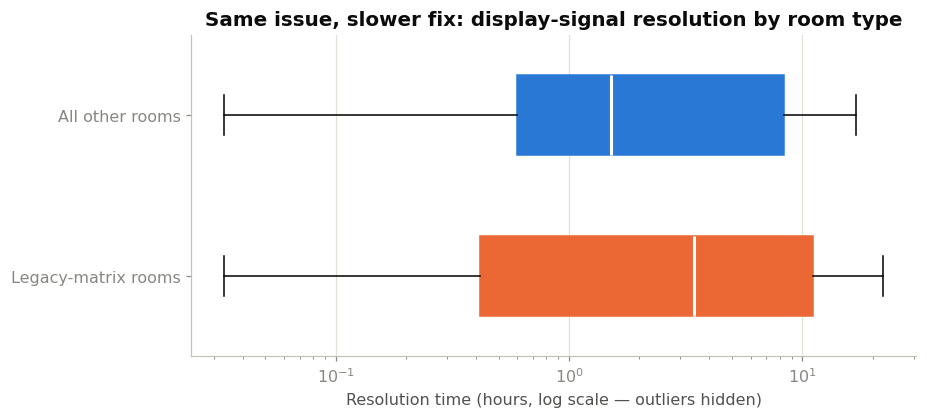

In [11]:
signal_subs = ["No display / HDMI handshake", "Input switching failure"]
sig_res = resolved[resolved.subcategory.isin(signal_subs) & resolved.has_room].copy()
sig_res["room_group"] = np.where(sig_res.config_variant == "legacy_matrix_v1",
                                 "Legacy-matrix rooms", "All other rooms")

grp = sig_res.groupby("room_group")["res_hours"].agg(["median", "size"]).round(1)
print("Display-signal issues only (calendar hours):")
print(grp)

GROUP_COLORS = {"Legacy-matrix rooms": "#eb6834", "All other rooms": "#2a78d6"}
fig, ax = plt.subplots(figsize=(8.5, 3.8))
data = [sig_res.loc[sig_res.room_group == g, "res_hours"] for g in GROUP_COLORS]
bp = ax.boxplot(data, vert=False, widths=0.5, patch_artist=True, showfliers=False,
                medianprops=dict(color="white", linewidth=2))
for patch, color in zip(bp["boxes"], GROUP_COLORS.values()):
    patch.set_facecolor(color); patch.set_edgecolor(color)
ax.set_yticklabels(GROUP_COLORS.keys())
ax.set_xscale("log")
ax.set_xlabel("Resolution time (hours, log scale — outliers hidden)")
ax.set_title("Same issue, slower fix: display-signal resolution by room type")
style_axh(ax)
fig.savefig(FIG_DIR / "resolution_compare.png")
plt.show()

Like-for-like, the legacy rooms' display-signal tickets take **more than twice as long at the
median** — technicians are diagnosing a flakier signal chain (matrix-switcher EDID
handshakes, firmware two majors behind) before they can isolate the fault. The naive
aggregate had the sign of the effect *backwards*; the mix correction reverses it. This
is the project's clearest lesson in composition effects.

## 5. The repeat-ticket pattern (the core finding)

A ticket is a **repeat** if the *same room* logs the *same subcategory* again within
**14 days**. Repeats are the expensive kind of ticket: the underlying cause survived
the fix. (Room-attributed tickets only — the 30% without a room can't participate.)

In [12]:
att = tickets[tickets.has_room].sort_values("created_at").copy()
prev = att.groupby(["classroom_id", "subcategory"])["created_at"].shift()
att["is_repeat"] = (att["created_at"] - prev).le(pd.Timedelta(days=14))

repeat_by_config = (att.groupby("config_label")
                    .agg(tickets=("ticket_id", "size"), repeats=("is_repeat", "sum")))
repeat_by_config["repeat_rate"] = (repeat_by_config.repeats / repeat_by_config.tickets)
repeat_by_config.sort_values("repeat_rate", ascending=False)

,tickets,repeats,repeat_rate
config_label,,,
Legacy matrix,282,103,0.365248
NVX early rollout,61,16,0.262295
NVX standard,196,37,0.188776


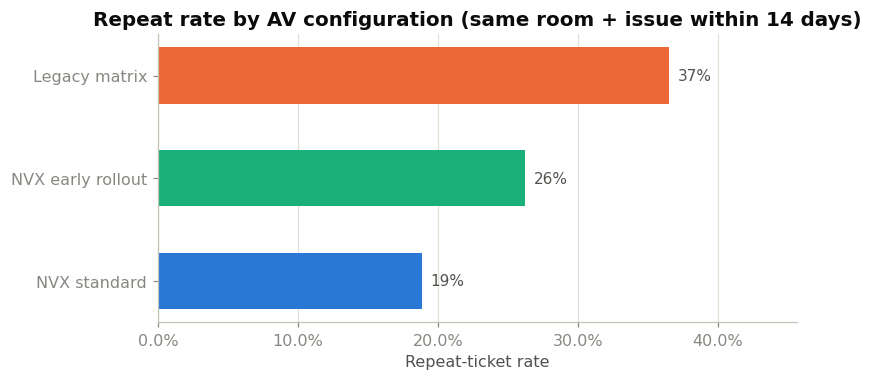

In [13]:
fig, ax = plt.subplots(figsize=(7.5, 3.4))
rr = repeat_by_config["repeat_rate"].sort_values()
inv = {v: k for k, v in CONFIG_LABELS.items()}
ax.barh(rr.index, rr.values, color=[CONFIG_COLORS[inv[l]] for l in rr.index], height=0.55)
style_axh(ax)
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
for i, v in enumerate(rr.values):
    ax.text(v + 0.006, i, f"{v:.0%}", va="center", fontsize=10, color=INK_2)
ax.set_title("Repeat rate by AV configuration (same room + issue within 14 days)")
ax.set_xlabel("Repeat-ticket rate")
ax.set_xlim(0, rr.max() * 1.25)
fig.savefig(FIG_DIR / "repeat_rate.png")
plt.show()

### 5.1 Volume concentration — the five legacy rooms lead the queue

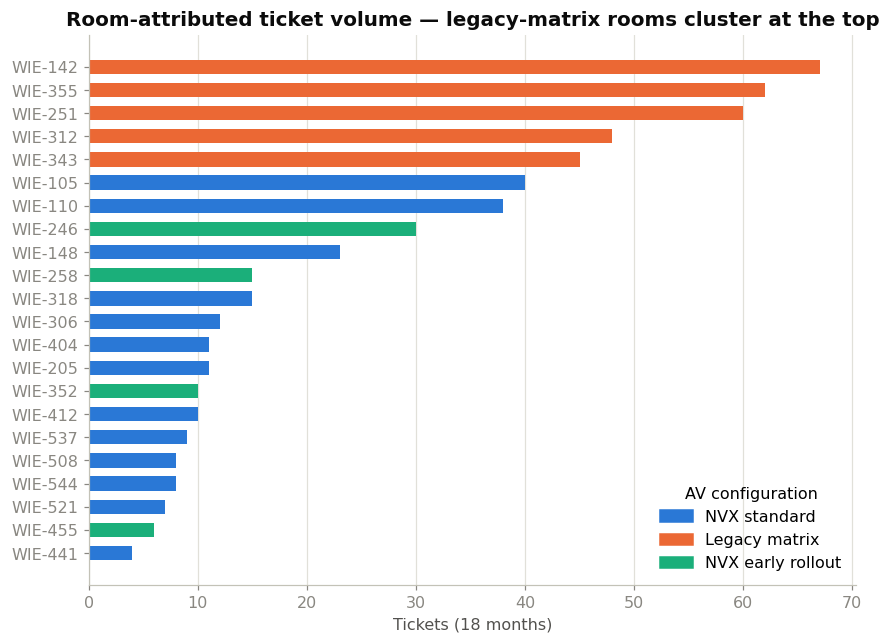

,tickets,rooms,tickets_per_room,share
config_label,,,,
Legacy matrix,282,5,56.4,52%
NVX early rollout,61,4,15.2,11%
NVX standard,196,13,15.1,36%


In [14]:
by_room = (att.groupby(["classroom_id", "config_variant"])
           .size().reset_index(name="n").sort_values("n"))

fig, ax = plt.subplots(figsize=(9, 6.5))
ax.barh(by_room["classroom_id"], by_room["n"],
        color=by_room["config_variant"].map(CONFIG_COLORS), height=0.62)
style_axh(ax)
handles = [plt.Rectangle((0, 0), 1, 1, color=CONFIG_COLORS[k]) for k in CONFIG_LABELS]
ax.legend(handles, CONFIG_LABELS.values(), title="AV configuration",
          loc="lower right", frameon=False)
ax.set_title("Room-attributed ticket volume — legacy-matrix rooms cluster at the top")
ax.set_xlabel("Tickets (18 months)")
fig.savefig(FIG_DIR / "volume_by_room.png")
plt.show()

share = att.groupby("config_label").size().to_frame("tickets")
share["rooms"] = rooms["config_variant"].map(CONFIG_LABELS).value_counts()
share["tickets_per_room"] = (share.tickets / share.rooms).round(1)
share["share"] = (share.tickets / share.tickets.sum()).map("{:.0%}".format)
share.sort_values("tickets_per_room", ascending=False)

Utilization is a confounder here — the legacy rooms are also heavily-taught core
rooms. The cleaner evidence isn't total volume; it's the *composition* and *behavior*
of their tickets, which utilization alone can't explain:

### 5.2 What fails in legacy rooms, when — and does it come back?

In [15]:
legacy_att = att[att.config_variant == "legacy_matrix_v1"]
mix = (att.assign(is_signal=att.subcategory.isin(signal_subs),
                  grp=np.where(att.config_variant == "legacy_matrix_v1",
                               "Legacy-matrix rooms", "Other rooms"))
       .groupby("grp")["is_signal"].mean())
print("Display-signal share of room tickets:")
print(mix.map("{:.0%}".format).to_string())

rep_sig = (legacy_att[legacy_att.subcategory.isin(signal_subs)]["is_repeat"].mean())
print(f"\nLegacy-room display-signal tickets recurring within 14 days: {rep_sig:.0%}")

Display-signal share of room tickets:
grp
Legacy-matrix rooms    38%
Other rooms            10%

Legacy-room display-signal tickets recurring within 14 days: 56%


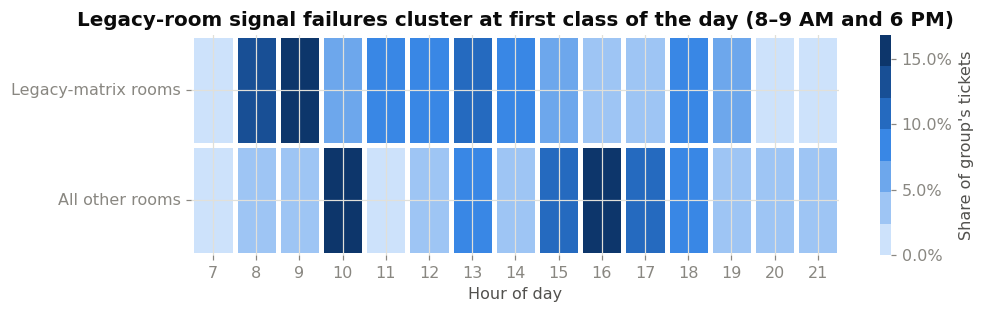

In [16]:
# Hour-of-day fingerprint for display-signal tickets: legacy vs other rooms
sig = att[att.subcategory.isin(signal_subs)].copy()
sig["grp"] = np.where(sig.config_variant == "legacy_matrix_v1",
                      "Legacy-matrix rooms", "All other rooms")
pivot = sig.groupby(["grp", "hour"]).size().unstack(fill_value=0)
pivot_norm = pivot.div(pivot.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(9.5, 2.6))
sns.heatmap(pivot_norm.reindex(["Legacy-matrix rooms", "All other rooms"]),
            cmap=sns.color_palette(SEQ_BLUES, as_cmap=True),
            linewidths=2, linecolor="white",
            cbar_kws={"label": "Share of group's tickets",
                      "format": mtick.PercentFormatter(1.0)}, ax=ax)
ax.set_title("Legacy-room signal failures cluster at first class of the day (8–9 AM and 6 PM)")
ax.set_xlabel("Hour of day"); ax.set_ylabel("")
ax.tick_params(rotation=0)
fig.savefig(FIG_DIR / "hourly_heatmap.png")
plt.show()

The fingerprint is diagnostic. In legacy-matrix rooms, display-signal failures pile
up at **8–9 AM** and again around **6 PM** — the first daytime class and the first
evening-program class, i.e., the first time each day a laptop hits a system that
powered on from cold. Other rooms track the building's general mid-day demand curve.
That's the signature of a **cold-start EDID handshake failure**, not random
cable or hardware faults.

### 5.3 Is the association statistically real?

In [17]:
ct = pd.crosstab(att.config_variant == "legacy_matrix_v1",
                 att.subcategory.isin(signal_subs))
ct.index = ["Other rooms", "Legacy-matrix rooms"]
ct.columns = ["Other issues", "Display-signal issues"]
chi2, p, dof, _ = stats.chi2_contingency(ct)

sig_share_grp = ct["Display-signal issues"] / ct.sum(axis=1)
print(ct, "\n")
print(f"Display-signal share — legacy rooms: {sig_share_grp['Legacy-matrix rooms']:.0%}"
      f" vs other rooms: {sig_share_grp['Other rooms']:.0%}")
print(f"Chi-square = {chi2:.1f}, p = {p:.1e}")

                     Other issues  Display-signal issues
Other rooms                   232                     25
Legacy-matrix rooms           175                    107 

Display-signal share — legacy rooms: 38% vs other rooms: 10%
Chi-square = 56.4, p = 6.0e-14


The association holds well beyond chance. *(Caveat to volunteer before anyone asks:
the test says legacy rooms' ticket mix is different; it can't by itself rule out that
something else about those five rooms — age, cabling, usage style — is the cause. The
mechanism evidence is the cold-start clustering plus the repeat behavior; the definitive
test is refreshing one room and watching a quarter of tickets.)*

## 6. The finding, in plain language

**The pattern:** Five heavily-used classrooms (WIE-142, WIE-251, WIE-312, WIE-343,
WIE-355) still run a 2017-era AV configuration: an HDMI matrix switcher with
**auto-input-switching disabled**, behind firmware two major versions old. In these
rooms:

- Display-signal issues are nearly **four times the share** of ticket volume seen elsewhere (38% vs 10%)
- Failures cluster at **first-class-of-the-day** times (8–9 AM, ~6 PM) — the cold-start
  EDID handshake signature
- The majority of their display-signal tickets **recur within 14 days** — power-cycling
  fixes the morning, not the configuration
- Like-for-like, those tickets take **more than twice as long to resolve** (median 3.4 vs 1.5 hours) as the same issues in
  standardized rooms

**The process improvements this analysis supports:**

1. **Standardize the five legacy rooms** on the current NVX configuration (interim:
   enable auto-input-switching, update firmware, replace podium HDMI cabling).
2. **Add a cold-start display check to opening walk-throughs** for those rooms until
   the refresh lands — power on and verify handshake before the first class, morning
   *and* before the evening block.
3. **Schedule preventative maintenance in the quiet weeks** (late December, late
   March, summer) directly before each demand peak.
4. **Make the room field required** on the AV request form — 30% of tickets currently
   can't participate in room-level analysis at all.

In [18]:
# Impact estimate: excess display-signal + repeat burden in legacy rooms
per_room = att.groupby("config_label").size() / rooms.groupby(
    rooms["config_variant"].map(CONFIG_LABELS)).size()
n_legacy = (rooms.config_variant == "legacy_matrix_v1").sum()

# Conservative frame: excess display-signal tickets vs other rooms' signal share
legacy_n = (att.config_variant == "legacy_matrix_v1").sum()
sig_legacy = (legacy_att.subcategory.isin(signal_subs)).sum()
other_share = att[att.config_variant != "legacy_matrix_v1"].subcategory.isin(signal_subs).mean()
excess_sig = sig_legacy - other_share * legacy_n

months = (tickets.created_at.max() - tickets.created_at.min()).days / 30.4
print(f"Legacy-room display-signal tickets: {sig_legacy} "
      f"(expected at other rooms' rate: {other_share * legacy_n:.0f})")
print(f"Excess display-signal tickets: {excess_sig:.0f} over {months:.0f} months "
      f"≈ {excess_sig * 12 / months:.0f}/year")
print(f"As share of ALL human AV tickets: {excess_sig / len(tickets):.0%} of volume")

Legacy-room display-signal tickets: 107 (expected at other rooms' rate: 27)
Excess display-signal tickets: 80 over 18 months ≈ 54/year
As share of ALL human AV tickets: 11% of volume


A deliberately **conservative** estimate: it only counts the excess display-signal
tickets (the failure mode the configuration directly causes), not the legacy rooms'
entire volume gap — utilization differences make the broader number less defensible.
Even so, eliminating the excess would remove roughly **one in ten human AV tickets**,
and specifically the class-blocking morning kind — plus the technician hours burned
re-fixing the same rooms.

## 7. Limitations

- **Synthetic data.** Distributions were calibrated to aggregate statistics from a real
  export, but the config→failure pattern itself is planted for demonstration; this
  project shows *method*, not a real discovery.
- **No teaching-hours denominator.** Per-room rates aren't normalized by actual class
  hours; utilization confounds raw volume comparisons (which is why the analysis leans
  on composition, timing, and repeat behavior instead).
- **30% missing room attribution** biases room-level metrics toward whatever gets
  reported with a room; the direction of that bias is unknown.
- **Calendar-time resolution metrics** mix queue time with work time; separating
  urgent and scheduled work mitigates but doesn't eliminate this.
- **Observational.** The clean causal test is the intervention: refresh one legacy
  room, watch its display-signal and repeat rates for a quarter against the other four.
